# 🚀 ETL: Consolidación Expo Móvil 2026

Este Notebook documenta la ejecución del proceso **Extract, Transform, and Load (ETL)** diseñado para centralizar las solicitudes de crédito de la Expo Móvil. El objetivo es unificar datos de múltiples fuentes (**fg_express, he_bpm_prend, he_bpm_leas y ultm_bpm**) en un reporte único de control operativo.

**Curso:** Fundamentos de Python | Universidad Castro Carazo.

**Nombre del estudiante:** ODEL LEAL HERNANDEZ

**Profesor:** Ing. Andrés Mena A.

---

## 📋 Descripción del Proyecto
Como parte de la optimización de flujos mediante **Python**, este script resuelve la fragmentación de datos y mejora la trazabilidad técnica en la recepción de solicitudes de crédito para vehículos.

### 🛠️ Stack Tecnológico
* **Pandas & Numpy**: Motor principal de transformación y lógica condicional.
* **JSON**: Gestión de parámetros externos (Tasas de cambio, límites de montos).
* **Glob & OS**: Automatización de lectura de archivos y gestión de directorios.

---

## ⚙️ Configuración y Reglas de Negocio
El proceso se alimenta de configuraciones dinámicas para facilitar ajustes sin modificar el código fuente:

* **`parametros.json`**: Define el **Tipo de Cambio ($₡475$ por defecto, pero parametrizable)**, prioridades de estado, reglas de validación y el modo de cierre.
* **`agencias_homologacion.xlsx`**: Diccionario maestro para unificar nombres de agencias, ya que en los sistemas los nombres de las agencias los ingresaron con diferencias. (ej. "Purdy Motor", "Danissa", "Grupo Q").
* **Validación de Montos**: Filtros automáticos basados en límites mínimos y máximos por moneda (CRC/USD).

---

## 🔄 Pipeline de Datos

### 1. Ingesta y Conversión
* El script escanea la carpeta `/data` y detecta archivos `.xls` (comúnmente exportados como tablas HTML desde un sistema antiguo).
* Realiza una conversión automática a **.xlsx nativo** para asegurar la integridad de la lectura.

### 2. Transformaciones Críticas
* **Limpieza de Identidad**: Estandarización de identificaciones (eliminación de guiones, espacios y ceros a la izquierda).
* **Deduplicación por Prioridad**: Si un cliente tiene múltiples gestiones, se mantiene la de mayor jerarquía (Aprobado > Condicionado > Rechazado).
* **Redistribución Estadística**: Los casos "En Proceso" se reclasifican y redistribuyen aleatoriamente basándose en la tasa de aprobación real del día.

---

## 📦 Entregables (Outputs)
Los resultados se generan con un *timestamp* único en la carpeta `/output`:

1. **Base Principal**: Consolidado total con estados homologados y montos dolarizados.
2. **Reporte Aprobaciones Express**: Listado exclusivo de aprobaciones inmediatas de Verdes en Firme.
3. **Resumen Diario**: Tabla resumen con volumen de solicitudes y eficiencia de aprobación (% Aprobación).
4. **Log de Proceso**: Archivo de texto con el detalle técnico de la ejecución y tiempos de duración.

---
> **Nota:** Este flujo asegura que la información entregada a la gerencia sea íntegra, deduplicada y bajo un estándar bancario profesional.

In [22]:
import pandas as pd
import numpy as np
import os
import glob
from datetime import datetime
import warnings
import json 

# Ignoramos alertas de Excel temporales para no saturar la pantalla
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

def ejecutar_etl_completo(tc_interfaz=None, modo_cierre_interfaz=None):
    """
    Función principal que encapsula todo el proceso ETL.
    tc_interfaz y modo_cierre_interfaz permiten recibir valores desde una app externa (ej. Streamlit).
    """
    
    # -----------------------------------------------------------------------------
    # 0. LECTURA DE PARÁMETROS EXTERNOS (.JSON)
    # -----------------------------------------------------------------------------
    ruta_config = "config"
    if not os.path.exists(ruta_config):
        os.makedirs(ruta_config)

    archivo_parametros = f"{ruta_config}/parametros.json"

    # Si no existe el archivo JSON, creamos una plantilla por defecto y la guardamos
    if not os.path.exists(archivo_parametros):
        parametros_base = {
            "ES_CIERRE": False,
            "NOMBRES_ARCHIVOS_SALIDA": {
                "PRINCIPAL": "Rep_Preliminar",
                "LOG": "Rep_Preliminar_log",
                "VERDES_FIRME": "Rep_Verde_En_Firme",
                "RESUMEN": "Rep_Resumen_Diario"
            },
            "TC_CRCUSD": 475.00,
            "PRIORIDADES_ESTADO": {
                "APROBADO": 1,
                "CONDICIONADO": 2,
                "RECHAZADO": 3,
                "EN PROCESO": 4
            },
            "LIMITES_VALIDACION_MONTOS": {
                "CRC": {"MINIMO": 3000000, "MAXIMO": 60000000},
                "USD": {"MINIMO": 6000, "MAXIMO": 150000}
            }
        }
        with open(archivo_parametros, "w", encoding="utf-8") as f:
            json.dump(parametros_base, f, indent=4)
        print(f"⚠️ Se creó archivo de parámetros base en: {archivo_parametros}")

    # Leemos los parámetros desde el archivo .json
    with open(archivo_parametros, "r", encoding="utf-8") as f:
        parametros = json.load(f)

    # Asignamos los parámetros a las variables del script. 
    ES_CIERRE = modo_cierre_interfaz if modo_cierre_interfaz is not None else parametros.get("ES_CIERRE", False)
    TC_CRCUSD = tc_interfaz if tc_interfaz is not None else parametros.get("TC_CRCUSD", 475.00)
    
    nombres_out = parametros.get("NOMBRES_ARCHIVOS_SALIDA", {})
    dicc_prioridad = parametros.get("PRIORIDADES_ESTADO", {})
    limites_montos = parametros.get("LIMITES_VALIDACION_MONTOS", {})

    prefijo_principal = nombres_out.get("PRINCIPAL", "Rep_Preliminar")
    prefijo_log = nombres_out.get("LOG", "Rep_Preliminar_log")
    prefijo_verdes = nombres_out.get("VERDES_FIRME", "Rep_Verde_En_Firme")
    prefijo_resumen = nombres_out.get("RESUMEN", "Rep_Resumen_Diario")

    # -----------------------------------------------------------------------------
    # CONFIGURACIÓN INICIAL Y LOGGING 
    # -----------------------------------------------------------------------------
    tiempo_inicio = datetime.now()
    timestamp = tiempo_inicio.strftime("%Y%m%d%H%M%S")

    # Carpetas donde se guardarán los resultados y los históricos (logs)
    ruta_output = "output"
    ruta_logs = f"{ruta_output}/logs"
    
    if not os.path.exists(ruta_output):
        os.makedirs(ruta_output)
    if not os.path.exists(ruta_logs):
        os.makedirs(ruta_logs)

    # El archivo de log de texto va directamente a la carpeta logs con timestamp
    archivo_log = f"{ruta_logs}/{prefijo_log}_{timestamp}.txt"

    def log_print(mensaje):
        print(mensaje)
        with open(archivo_log, "a", encoding="utf-8") as file:
            file.write(mensaje + "\n")

    log_print(f"============================================================")
    log_print(f"🚀 INICIANDO PROCESO ETL EXPO MOVIL")
    log_print(f"🕒 Fecha y Hora de Inicio: {tiempo_inicio.strftime('%Y-%m-%d %H:%M:%S')}")
    log_print(f"⚙️ MODO CIERRE ACTIVADO: {ES_CIERRE}")
    log_print(f"============================================================\n")

    ruta_data = "data"

    if not os.path.exists(ruta_data):
        os.makedirs(ruta_data)
        log_print(f"⚠️ Se creó la carpeta '{ruta_data}'. Por favor coloca ahí los archivos y vuelve a ejecutar.")

    # -----------------------------------------------------------------------------
    # 1. CONVERSIÓN ARCHIVOS XLS A XLSX
    # -----------------------------------------------------------------------------
    log_print("➡️ PASO 1: Buscando y convirtiendo archivos .xls a .xlsx...")
    archivos_xls = glob.glob(f"{ruta_data}/*.xls")

    if archivos_xls:
        for archivo in archivos_xls:
            try:
                log_print(f"   Convirtiendo: {archivo}")
                try:
                    df_temp = pd.read_excel(archivo, engine="xlrd")
                except:
                    try:
                        log_print(f"      ⚠️ Formato dudoso detectado. Intentando leer como tabla HTML...")
                        df_temp = pd.read_html(archivo)[0]
                    except:
                        log_print(f"      ⚠️ Intentando leer como texto separado por tabulaciones...")
                        df_temp = pd.read_csv(archivo, sep='\t')

                nuevo_nombre = archivo + "x" 
                df_temp.to_excel(nuevo_nombre, index=False)
                os.remove(archivo) 
                log_print(f"   ✅ Conversión exitosa: {nuevo_nombre}")
                
            except Exception as e:
                log_print(f"   ❌ Error final convirtiendo {archivo}. Detalle: {e}")
                log_print(f"      👉 Sugerencia: Abre el archivo manualmente en Excel, dale 'Guardar Como' -> 'Libro de Excel (.xlsx)'")
    else:
        log_print("   No se encontraron archivos .xls para convertir. ¡Todo en orden!")

    # -----------------------------------------------------------------------------
    # 2, 3, 4 y 5. IMPORTAR, LEER COLUMNAS, TIPADO Y RENOMBRADO
    # -----------------------------------------------------------------------------
    log_print("\n➡️ PASOS 2 al 5: Leyendo, tipando y renombrando Dataframes...")

    configs_archivos = {
        "fg_express": {
            "file": f"{ruta_data}/fg_express.xlsx",
            "cols": ["IDOPERATION", "CUSTOMERID", "CREATEDDATE", "NAME", "STATUS_GENERAL", "Comercio Sucursal", "Moneda Credito", "Agencia", "Marca", "Estilo", "Monto Financiar", "Ejecutivo", "Ejecutivo Email", "Usuario", "SCORE_FILL"],
            "types": {"CUSTOMERID": str, "Monto Financiar": float},
            "dates": ["CREATEDDATE"],
            "rename": {
                "IDOPERATION": "SOLICITUD", "CUSTOMERID": "IDENTIFICACION", "CREATEDDATE": "FECHA_SOLICITUD",
                "STATUS_GENERAL": "ESTADO", "Moneda Credito": "MONEDA_CREDITO", "Agencia": "AGENCIA",
                "Marca": "MARCA", "Monto Financiar": "MONTO_CREDITO", "SCORE_FILL": "SCORE_FILL",
                "NAME": "NAME", "Comercio Sucursal": "Comercio Sucursal", "Estilo": "Estilo", 
                "Ejecutivo": "Ejecutivo", "Ejecutivo Email": "Ejecutivo Email", "Usuario": "Usuario"
            },
            "canal": "FG-EXPRESS"
        },
        "he_bpm_prend": {
            "file": f"{ruta_data}/he_bpm_prend.xlsx",
            "cols": ["Solicitud", "Fecha de Solicitud", "Etapa", "Numero de Identificación", "Agencia (Agencia del Vehiculo)", "Marca (Marca de Vehiculo)", "Moneda (Moneda del Credito)", "Monto del Credito"],
            "types": {"Numero de Identificación": str, "Monto del Credito": float},
            "dates": ["Fecha de Solicitud"],
            "rename": {
                "Solicitud": "SOLICITUD", "Fecha de Solicitud": "FECHA_SOLICITUD", "Etapa": "ESTADO",
                "Numero de Identificación": "IDENTIFICACION", "Agencia (Agencia del Vehiculo)": "AGENCIA",
                "Marca (Marca de Vehiculo)": "MARCA", "Moneda (Moneda del Credito)": "MONEDA_CREDITO",
                "Monto del Credito": "MONTO_CREDITO"
            },
            "canal": "HE-BPM"
        },
        "he_bpm_leas": {
            "file": f"{ruta_data}/he_bpm_leas.xlsx",
            "cols": ["Solicitud", "Fecha de Solicitud", "Etapa", "Numero de Identificacion", "Monto del credito", "Moneda (Moneda)", "Agencia", "Marca"],
            "types": {"Numero de Identificacion": str, "Monto del credito": float},
            "dates": ["Fecha de Solicitud"],
            "rename": {
                "Solicitud": "SOLICITUD", "Fecha de Solicitud": "FECHA_SOLICITUD", "Etapa": "ESTADO",
                "Numero de Identificacion": "IDENTIFICACION", "Monto del credito": "MONTO_CREDITO",
                "Moneda (Moneda)": "MONEDA_CREDITO", "Agencia": "AGENCIA", "Marca": "MARCA"
            },
            "canal": "HE-BPM"
        },
        "ultm_bpm": {
            "file": f"{ruta_data}/ultm_bpm.xlsx",
            "cols": ["Fecha Cotiza", "Incidente", "Identificación", "Agencia Vehículo", "Marca Vehículo", "Moneda", "Monto Préstamo", "Decisión Crédito"],
            "types": {"Identificación": str, "Monto Préstamo": float},
            "dates": ["Fecha Cotiza"],
            "rename": {
                "Fecha Cotiza": "FECHA_SOLICITUD", "Incidente": "SOLICITUD", "Identificación": "IDENTIFICACION",
                "Agencia Vehículo": "AGENCIA", "Marca Vehículo": "MARCA", "Moneda": "MONEDA_CREDITO",
                "Monto Préstamo": "MONTO_CREDITO", "Decisión Crédito": "ESTADO"
            },
            "canal": "ULTM-BPM"
        }
    }

    lista_dataframes = []

    for nombre, config in configs_archivos.items():
        if os.path.exists(config["file"]):
            log_print(f"   Procesando: {config['file']}")
            
            df = pd.read_excel(
                config["file"], 
                usecols=config["cols"], 
                dtype=config["types"]
            )
            
            for col_fecha in config["dates"]:
                if col_fecha in df.columns:
                    df[col_fecha] = pd.to_datetime(df[col_fecha], dayfirst=True, errors='coerce')
            
            df = df.rename(columns=config["rename"])
            df["CANAL"] = config["canal"]
            lista_dataframes.append(df)
        else:
            log_print(f"   ⚠️ ADVERTENCIA: No se encontró el archivo {config['file']}. Se omitirá en el consolidado.")

    # -----------------------------------------------------------------------------
    # 6. CONSOLIDACIÓN DE DATAFRAMES EN UNO
    # -----------------------------------------------------------------------------
    log_print("\n➡️ PASO 6: Consolidando (append) y aplicando limpiezas base...")
    if len(lista_dataframes) == 0:
        log_print("❌ ERROR CRÍTICO: No hay datos para consolidar. El script se detendrá.")
        return pd.DataFrame(), pd.DataFrame()

    df_consolidado = pd.concat(lista_dataframes, ignore_index=True)
    log_print(f"   Total de registros consolidados: {len(df_consolidado)}")

    df_consolidado['IDENTIFICACION'] = (
        df_consolidado['IDENTIFICACION']
        .astype(str)
        .str.strip()
        .str.replace("-", "", regex=False)
        .str.lstrip("0")
        .str.replace(" ", "", regex=False)
    )

    columnas_a_mayusculas = ["IDENTIFICACION", "AGENCIA", "MARCA", "MONEDA_CREDITO", "ESTADO"]
    for col in columnas_a_mayusculas:
        if col in df_consolidado.columns:
            df_consolidado[col] = df_consolidado[col].astype(str).str.upper().str.strip()

    df_consolidado['MONEDA_CREDITO'] = df_consolidado['MONEDA_CREDITO'].replace(
        {"COLONES": "CRC", "DOLARES": "USD"}
    )

    df_consolidado['MONTO_CREDITO_DOLARIZADO'] = np.where(
        df_consolidado['MONEDA_CREDITO'] == 'CRC',
        df_consolidado['MONTO_CREDITO'] / TC_CRCUSD,
        df_consolidado['MONTO_CREDITO']
    )

    # -----------------------------------------------------------------------------
    # 7. LÓGICA DE LIMPIEZA Y TRANSFORMACIÓN DE DATOS
    # -----------------------------------------------------------------------------
    log_print("\n➡️ PASO 7: Aplicando Reglas de Negocio (Estados, Prioridades y Validaciones)...")

    dicc_estados = {
        "APROBADO - VERDE EN FIRME": "APROBADO", "APROBADO": "APROBADO", "APROBAR": "APROBADO",
        "VB EJECUTIVO": "APROBADO", "EN CAMBIOS CARATULA": "APROBADO", "CAMBIOS NO PROCEDEN": "APROBADO",
        "EN CAMBIOS": "APROBADO", "SEGUROS": "APROBADO", "RECOMIENDA": "APROBADO",
        "CONDICIONADO": "CONDICIONADO", "CONDICIONADO PERSONA EXTRANJERA": "CONDICIONADO",
        "DENEGADO": "RECHAZADO", "RECHAZO": "RECHAZADO", "RECHAZAR": "RECHAZADO",
        "DESCARTADO ERROR EN SCORING": "RECHAZADO", "DESCARTADO": "RECHAZADO", "ANALISIS": "EN PROCESO",
        "ANÁLISIS DE DEVOLUCIÓN": "EN PROCESO", "DEVOLUCION": "EN PROCESO", "INICIO": "EN PROCESO",
        "IR A COTIZACION": "EN PROCESO", "": "EN PROCESO", "NAN": "EN PROCESO"
    }
    df_consolidado['ESTADO_HOMOLOGADO'] = df_consolidado['ESTADO'].map(dicc_estados).fillna("EN PROCESO")

    df_consolidado['DIA'] = df_consolidado['FECHA_SOLICITUD'].dt.day

    df_consolidado['PRIORIDAD'] = df_consolidado['ESTADO_HOMOLOGADO'].map(dicc_prioridad)

    log_print(f"   Eliminando duplicados de Identificación manteniendo la prioridad más alta (1=Aprobado)...")
    df_consolidado = df_consolidado.sort_values(by='PRIORIDAD', ascending=True)
    df_consolidado = df_consolidado.drop_duplicates(subset=['IDENTIFICACION'], keep='first')
    log_print(f"   Registros únicos después de limpiar duplicados: {len(df_consolidado)}")

    df_consolidado['ESTADO_CORREGIDO'] = np.where(
        df_consolidado['ESTADO_HOMOLOGADO'] == "EN PROCESO", 
        "CONDICIONADO", 
        df_consolidado['ESTADO_HOMOLOGADO']
    )

    def redistribucion_condicionados(df):
        aprobados = len(df[df['ESTADO_CORREGIDO'] == 'APROBADO'])
        rechazados = len(df[df['ESTADO_CORREGIDO'] == 'RECHAZADO'])
        base = aprobados + rechazados
        
        tasa_aprobacion = 0 if base == 0 else aprobados / base
        log_print(f"   > Tasa de aprobación calculada: {tasa_aprobacion:.2%}")

        condicionados = df[df['ESTADO_CORREGIDO'] == 'CONDICIONADO'].copy()
        otros = df[df['ESTADO_CORREGIDO'] != 'CONDICIONADO'].copy()
        
        if len(condicionados) == 0:
            df['ESTADO_FINAL'] = df['ESTADO_CORREGIDO']
            return df

        cant_a_aprobar = int(round(len(condicionados) * tasa_aprobacion, 0))
        log_print(f"   > Se redistribuirán {cant_a_aprobar} condicionados a APROBADO y {len(condicionados)-cant_a_aprobar} a RECHAZADO.")

        if cant_a_aprobar > 0:
            aprobados_azar = condicionados.sample(n=cant_a_aprobar, random_state=42)
            condicionados.loc[aprobados_azar.index, 'ESTADO_FINAL'] = 'APROBADO'
            condicionados.loc[~condicionados.index.isin(aprobados_azar.index), 'ESTADO_FINAL'] = 'RECHAZADO'
        else:
            condicionados['ESTADO_FINAL'] = 'RECHAZADO'

        otros['ESTADO_FINAL'] = otros['ESTADO_CORREGIDO']
        
        return pd.concat([otros, condicionados], ignore_index=True)

    df_consolidado = redistribucion_condicionados(df_consolidado)

    archivo_homologacion = f"{ruta_config}/agencias_homologacion.xlsx"

    if not os.path.exists(archivo_homologacion):
        dicc_agencias_base = {
            "AGENCIA DANISSA" : "DANISSA", "AGENCIA DATSUN" : "DANISSA", "AMBACAR " : "AMBACAR",
            "AMBACAR" : "AMBACAR", "AMBACAR S.A." : "AMBACAR", "AUTO STAR" : "AUTO STAR",
            "AUTOMOTRIZ CR CA S.A." : "PURDY MOTOR", "AUTOMOTRIZ CR/CA" : "PURDY MOTOR", "BAIC" : "CORI MOTORS",
            "BAVARIAN MOTORS" : "BAVARIAN MOTORS", "CORI CAR" : "CORI CAR", "CORI MOTORS" : "CORI MOTORS",
            "CORI MOTORS S.A" : "CORI MOTORS", "CORPORACIÓN GRUPO Q" : "GRUPO Q", "DANISSA" : "DANISSA",
            "DISTRITO AUTOMOTRIZ" : "INCHCAPE", "ELECTRO AUTOS" : "ELECTRO AUTOS", "EURO ADVANCE" : "OMOJAE MOTORS (EURO ADVANCE)",
            "EURO ADVANCE S.A" : "OMOJAE MOTORS (EURO ADVANCE)", "FACO" : "FACO", "GRAND MOTORS" : "GRAND MOTORS",
            "GRUPO DANISSA" : "DANISSA", "GRUPO Q" : "GRUPO Q", "INCHCAPE" : "INCHCAPE",
            "INCHCAPOE" : "INCHCAPE", "KIA" : "QUALITY MOTORS", "MOTORES BRITÁNICOS" : "MOTORES BRITÁNICOS",
            "MOTORES BRITÁNICOS (GAC MOTOR)" : "MOTORES BRITÁNICOS", "MOTORES BRITÁNICOS DE CR" : "MOTORES BRITÁNICOS",
            "OMOJAE MOTORS" : "OMOJAE MOTORS (EURO ADVANCE)", "OMOJAE MOTORS (EURO ADVANCE)" : "OMOJAE MOTORS (EURO ADVANCE)",
            "PACIFIC MOTORS S.A" : "AUTO STAR", "PURDY MOTOR" : "PURDY MOTOR", "QUALITY MOTORS" : "QUALITY MOTORS",
            "SAVA-FACO" : "FACO", "TOYO DEL ATLANTICO" : "TOYO DEL ATLANTICO", "VEINSA" : "VEINSA",
            "VEINSA MOTORS" : "VEINSA", "VETRASA" : "INCHCAPE"
        }
        df_base = pd.DataFrame(list(dicc_agencias_base.items()), columns=["AGENCIA_ORIGEN", "AGENCIA_HOMOLOGADA"])
        df_base.to_excel(archivo_homologacion, index=False)
        log_print(f"   ⚠️ Se creó la plantilla de configuración de agencias en: {archivo_homologacion}")

    try:
        df_agencias = pd.read_excel(archivo_homologacion)
        dicc_agencias = dict(zip(
            df_agencias.iloc[:, 0].astype(str).str.upper().str.strip(),
            df_agencias.iloc[:, 1].astype(str).str.upper().str.strip()
        ))
        log_print(f"   > Diccionario de agencias cargado desde Excel ({len(dicc_agencias)} mapeos).")
    except Exception as e:
        log_print(f"   ❌ Error leyendo {archivo_homologacion}: {e}")
        dicc_agencias = {}

    df_consolidado['AGENCIA'] = df_consolidado['AGENCIA'].map(dicc_agencias).fillna(df_consolidado['AGENCIA'] + "***NO HOMOLOG**")

    log_print("   Generando validaciones de Montos y Monedas...")

    min_crc = limites_montos.get("CRC", {}).get("MINIMO", 3000000)
    max_crc = limites_montos.get("CRC", {}).get("MAXIMO", 60000000)
    min_usd = limites_montos.get("USD", {}).get("MINIMO", 6000)
    max_usd = limites_montos.get("USD", {}).get("MAXIMO", 150000)

    cond_crc = (df_consolidado['MONEDA_CREDITO'] == 'CRC') & ((df_consolidado['MONTO_CREDITO'] < min_crc) | (df_consolidado['MONTO_CREDITO'] > max_crc))
    cond_usd = (df_consolidado['MONEDA_CREDITO'] == 'USD') & ((df_consolidado['MONTO_CREDITO'] < min_usd) | (df_consolidado['MONTO_CREDITO'] > max_usd))

    df_consolidado['VALIDACION'] = np.where(cond_crc | cond_usd, "REVISE", "OK")

    # -----------------------------------------------------------------------------
    # 8. SELECCION Y ORDEN DE COLUMNAS
    # -----------------------------------------------------------------------------
    log_print("\n➡️ PASO 8: Ordenando columnas finales...")
    columnas_finales = [
        "SOLICITUD", "CANAL", "IDENTIFICACION", "FECHA_SOLICITUD", "ESTADO",
        "ESTADO_HOMOLOGADO", "ESTADO_CORREGIDO", "ESTADO_FINAL", "MONEDA_CREDITO",
        "MONTO_CREDITO", "MONTO_CREDITO_DOLARIZADO", "AGENCIA", "MARCA",
        "SCORE_FILL", "VALIDACION", "PRIORIDAD", "DIA"
    ]

    for col in columnas_finales:
        if col not in df_consolidado.columns:
            df_consolidado[col] = np.nan

    df_consolidado = df_consolidado[columnas_finales]

    # -----------------------------------------------------------------------------
    # 9. EXPORTADO FINAL DATAFRAMES PRINCIPALES
    # -----------------------------------------------------------------------------
    log_print(f"\n➡️ PASO 9: Exportando archivos a Excel en carpetas correspondientes...")

    # --- Extraer Verdes en Firme EXCLUSIVO de Fill&Go ---
    log_print("   Generando reporte exclusivo de 'APROBADO - VERDE EN FIRME'...")
    df_verdes_firme = df_consolidado[(df_consolidado['CANAL'] == 'FG-EXPRESS') & (df_consolidado['ESTADO'] == 'APROBADO - VERDE EN FIRME')].copy()

    archivo_excel_verdes_ts = f"{ruta_logs}/{prefijo_verdes}_{timestamp}.xlsx" # Con marca en logs/
    archivo_excel_verdes = f"{ruta_output}/{prefijo_verdes}.xlsx"              # Sin marca en output/

    if not df_verdes_firme.empty:
        try:
            df_verdes_firme.to_excel(archivo_excel_verdes, index=False)
            df_verdes_firme.to_excel(archivo_excel_verdes_ts, index=False)
            log_print(f"   ✅ Archivo de Verdes en Firme generado en output y logs ({len(df_verdes_firme)} registros)")
        except Exception as e:
            log_print(f"   ❌ Error exportando archivo de Verdes en Firme: {e}")
    else:
        log_print("   ⚠️ No se detectaron registros 'APROBADO - VERDE EN FIRME' provenientes de FG-EXPRESS tras la limpieza.")

    # --- Exportar Base Consolidada Principal ---
    log_print("   Generando reporte consolidado principal...")
    archivo_excel_ts = f"{ruta_logs}/{prefijo_principal}_{timestamp}.xlsx" # Con marca en logs/
    archivo_excel = f"{ruta_output}/{prefijo_principal}.xlsx"              # Sin marca en output/
    
    try:
        df_consolidado.to_excel(archivo_excel, index=False)
        df_consolidado.to_excel(archivo_excel_ts, index=False)
        log_print(f"   ✅ Archivo Principal generado en output y logs ({len(df_consolidado)} registros)")
    except Exception as e:
        log_print(f"   ❌ Error exportando el archivo excel principal: {e}")

    # -----------------------------------------------------------------------------
    # 10. GENERACIÓN DE REPORTE RESUMEN (DINÁMICO)
    # -----------------------------------------------------------------------------
    log_print("\n➡️ PASO 10: Generando reporte resumen diario...")

    columna_aprobado = 'ESTADO_HOMOLOGADO' if ES_CIERRE else 'ESTADO_FINAL'
    df_temp = df_consolidado.copy()

    df_temp['es_aprobado'] = (df_temp[columna_aprobado] == 'APROBADO').astype(int)
    df_temp['no_es_fill'] = (df_temp['CANAL'] != 'FG-EXPRESS').astype(int)
    df_temp['aprob_sin_fill'] = df_temp['es_aprobado'] * df_temp['no_es_fill']

    df_resumen = df_temp.groupby('DIA').agg(
        Q_TOTAL=('SOLICITUD', 'count'),                         
        Q_TOTAL_SIN_FILL_N_GO=('no_es_fill', 'sum'),            
        Q_TOTAL_APROB=('es_aprobado', 'sum'),                   
        Q_TOTAL_APROB_SIN_FILL_N_GO=('aprob_sin_fill', 'sum')   
    ).reset_index()

    df_resumen['%APROB_DIARIO'] = np.where(
        df_resumen['Q_TOTAL'] > 0, 
        df_resumen['Q_TOTAL_APROB'] / df_resumen['Q_TOTAL'], 
        0
    )

    df_resumen['%APROB_DIARIO_SIN_FILL_N_GO'] = np.where(
        df_resumen['Q_TOTAL_SIN_FILL_N_GO'] > 0, 
        df_resumen['Q_TOTAL_APROB_SIN_FILL_N_GO'] / df_resumen['Q_TOTAL_SIN_FILL_N_GO'], 
        0
    )

    archivo_resumen_ts = f"{ruta_logs}/{prefijo_resumen}_{timestamp}.xlsx" # Con marca en logs/
    archivo_resumen = f"{ruta_output}/{prefijo_resumen}.xlsx"              # Sin marca en output/
    
    try:
        df_resumen.to_excel(archivo_resumen, index=False)
        df_resumen.to_excel(archivo_resumen_ts, index=False)
        log_print(f"   ✅ Archivo Resumen generado en output y logs")
    except Exception as e:
        log_print(f"   ❌ Error exportando el archivo resumen: {e}")

    tiempo_fin = datetime.now()
    duracion = tiempo_fin - tiempo_inicio

    log_print(f"\n============================================================")
    log_print(f"🏁 PROCESO FINALIZADO")
    log_print(f"🕒 Fecha y Hora de Fin: {tiempo_fin.strftime('%Y-%m-%d %H:%M:%S')}")
    log_print(f"⏳ Tiempo de duración: {duracion.total_seconds():.2f} segundos")
    log_print(f"============================================================")

    return df_consolidado, df_resumen

if __name__ == "__main__":
    df_final, df_resumen_final = ejecutar_etl_completo()

🚀 INICIANDO PROCESO ETL EXPO MOVIL
🕒 Fecha y Hora de Inicio: 2026-04-12 23:30:39
⚙️ MODO CIERRE ACTIVADO: False

➡️ PASO 1: Buscando y convirtiendo archivos .xls a .xlsx...
   No se encontraron archivos .xls para convertir. ¡Todo en orden!

➡️ PASOS 2 al 5: Leyendo, tipando y renombrando Dataframes...
   Procesando: data/fg_express.xlsx
   Procesando: data/he_bpm_prend.xlsx
   Procesando: data/he_bpm_leas.xlsx
   Procesando: data/ultm_bpm.xlsx

➡️ PASO 6: Consolidando (append) y aplicando limpiezas base...
   Total de registros consolidados: 3339

➡️ PASO 7: Aplicando Reglas de Negocio (Estados, Prioridades y Validaciones)...
   Eliminando duplicados de Identificación manteniendo la prioridad más alta (1=Aprobado)...
   Registros únicos después de limpiar duplicados: 3331
   > Tasa de aprobación calculada: 45.09%
   > Se redistribuirán 216 condicionados a APROBADO y 263 a RECHAZADO.
   > Diccionario de agencias cargado desde Excel (49 mapeos).
   Generando validaciones de Montos y Mone

## Gráficos y análisis
### Importar la librería y los dataframes

In [36]:
## Leer los archivos de salida para graficar en notebook (esto se puede comentar si solo se quiere ejecutar el proceso ETL sin la parte de visualización)
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

# Rutas de los archivos fijos esperados
ruta_principal = "output/Rep_Preliminar.xlsx"
ruta_resumen = "output/Rep_Resumen_Diario.xlsx"

df = pd.read_excel(ruta_principal)
df_resumen = pd.read_excel(ruta_resumen)    
df.head()



,SOLICITUD,CANAL,IDENTIFICACION,FECHA_SOLICITUD,ESTADO,ESTADO_HOMOLOGADO,ESTADO_CORREGIDO,ESTADO_FINAL,MONEDA_CREDITO,MONTO_CREDITO,MONTO_CREDITO_DOLARIZADO,AGENCIA,MARCA,SCORE_FILL,VALIDACION,PRIORIDAD,DIA
0,2017857,FG-EXPRESS,616361646,2025-03-20 14:37:38,APROBADO - VERDE EN FIRME,APROBADO,APROBADO,APROBADO,USD,20920.0,20920.0,DANISSA,NISSAN,646.0,OK,1,20
1,2018751,FG-EXPRESS,873374917,2025-03-20 20:23:09,APROBADO - VERDE EN FIRME,APROBADO,APROBADO,APROBADO,USD,21000.0,21000.0,DANISSA,NISSAN,859.0,OK,1,20
2,2019407,FG-EXPRESS,643840511,2025-03-21 11:59:47,APROBADO - VERDE EN FIRME,APROBADO,APROBADO,APROBADO,USD,21000.0,21000.0,DANISSA,NISSAN,774.0,OK,1,21
3,2019909,FG-EXPRESS,828437424,2025-03-21 14:40:35,APROBADO - VERDE EN FIRME,APROBADO,APROBADO,APROBADO,USD,21000.0,21000.0,DANISSA,NISSAN,861.0,OK,1,21
4,2035962,FG-EXPRESS,986153044,2025-03-29 13:01:33,APROBADO - VERDE EN FIRME,APROBADO,APROBADO,APROBADO,USD,20800.0,20800.0,DANISSA,NISSAN,661.0,OK,1,29


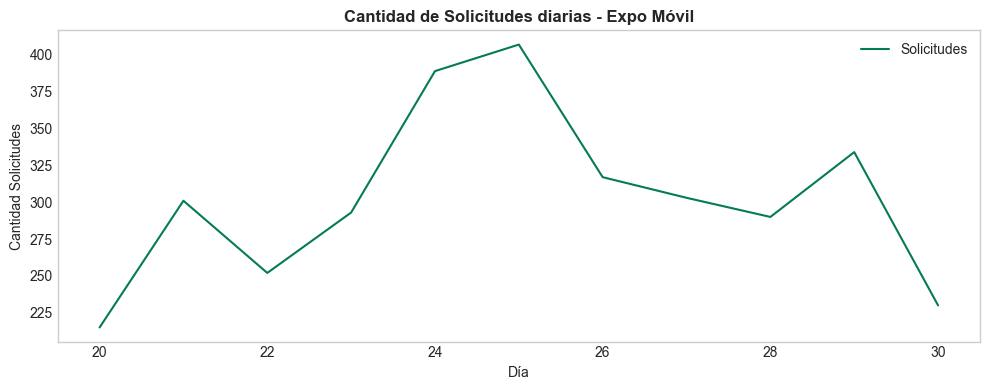

In [51]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.grid(False)

# CANTIDAD TOTAL DE SOLICITUDES DIARIAS
cant_solicitudes = df.groupby("DIA")["SOLICITUD"].count().reset_index(name="CANTIDAD_SOLICITUDES")
ax.plot(cant_solicitudes["DIA"], cant_solicitudes["CANTIDAD_SOLICITUDES"], linestyle="-", color="#057A57", label="Solicitudes")


ax.set_title("Cantidad de Solicitudes diarias - Expo Móvil", fontweight="bold")
ax.set_xlabel("Día")
ax.set_ylabel("Cantidad Solicitudes")
ax.legend()



plt.tight_layout()
plt.show()

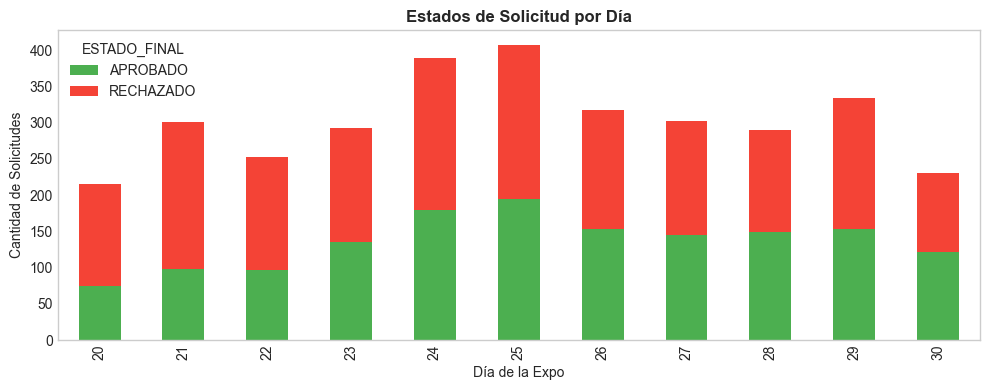

In [50]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.grid(False)

df_canal_dia = df.groupby(['DIA', 'ESTADO_FINAL']).size().unstack(fill_value=0)

colores_estados = {'APROBADO': '#4CAF50', 'CONDICIONADO': '#FFC107', 'RECHAZO': '#F44336', 'RECHAZADO': '#F44336'}
colores_usados = [colores_estados.get(col, '#9E9E9E') for col in df_canal_dia.columns]

df_canal_dia.plot(kind='bar', stacked=True, ax=ax, color=colores_usados, grid=False)

ax.set_title("Estados de Solicitud por Día", fontweight="bold")
ax.set_xlabel("Día de la Expo")
ax.set_ylabel("Cantidad de Solicitudes")
plt.tight_layout()
plt.show()

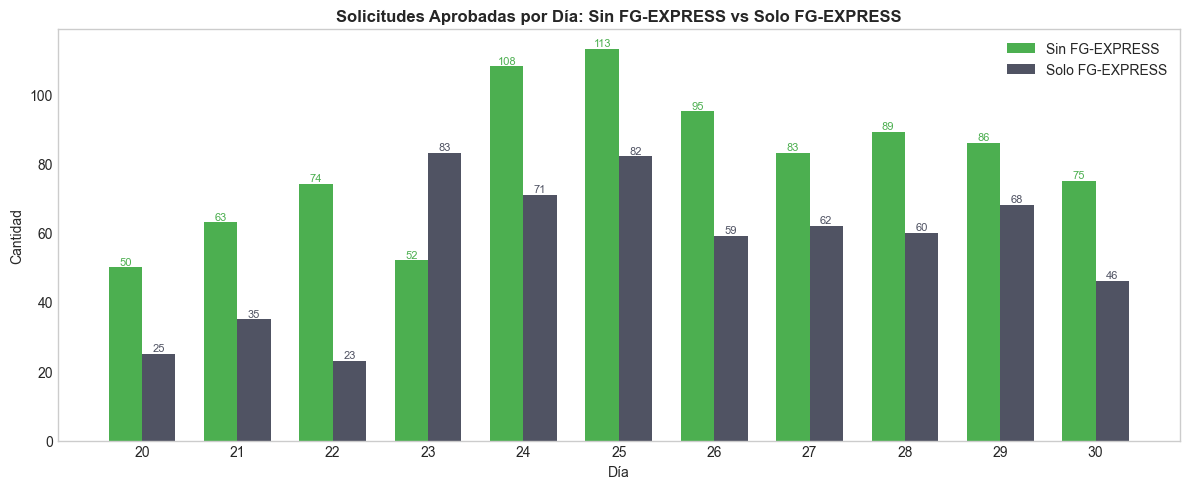

In [86]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.grid(False)

# Cantidad de solicitudes Aprobadas por día sin Fill&Go y solo FG-EXPRESS
df_aprobadas_sin_fill = df[(df['CANAL'] != 'FG-EXPRESS') & (df['ESTADO_FINAL'] == 'APROBADO')]
df_aprobadas_solo_fill = df[(df['CANAL'] == 'FG-EXPRESS') & (df['ESTADO_FINAL'] == 'APROBADO')]

cant_aprobadas_sin_fill = df_aprobadas_sin_fill.groupby("DIA")["SOLICITUD"].count().rename("SIN_FG")
cant_aprobadas_solo_fill = df_aprobadas_solo_fill.groupby("DIA")["SOLICITUD"].count().rename("CON_FG")

df_barras = pd.concat([cant_aprobadas_sin_fill, cant_aprobadas_solo_fill], axis=1).fillna(0).astype(int)
df_barras = df_barras.sort_index()

x = np.arange(len(df_barras.index))
width = 0.35

ax.bar(x - width/2, df_barras["SIN_FG"], width, label="Sin FG-EXPRESS", color="#4CAF50")
ax.bar(x + width/2, df_barras["CON_FG"], width, label="Solo FG-EXPRESS", color="#505363")

ax.set_title("Solicitudes Aprobadas por Día: Sin FG-EXPRESS vs Solo FG-EXPRESS", fontweight="bold")
ax.set_xlabel("Día")
ax.set_ylabel("Cantidad")
ax.set_xticks(x)
ax.set_xticklabels(df_barras.index, rotation=0)
ax.legend(frameon=False)

for idx, value in enumerate(df_barras["SIN_FG"]):
    ax.text(idx - width/2, value + 0.2, str(value), ha="center", va="bottom", fontsize=8, color="#4CAF50")
for idx, value in enumerate(df_barras["CON_FG"]):
    ax.text(idx + width/2, value + 0.2, str(value), ha="center", va="bottom", fontsize=8, color="#505363")

plt.tight_layout()
plt.show()

